# cluster image topics with BERTopic method

In [1]:
%%capture
!pip install bertopic

In [2]:
import numpy as np
import re
import pandas as pd
import warnings
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP
#from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df1=pd.read_csv('/content/drive/My Drive/Colab Notebooks/phd project/BLIP results.csv', encoding='utf-8')
df2=pd.read_csv('/content/drive/My Drive/Colab Notebooks/phd project/zero shot result for image topics.csv', encoding='utf-8')
#df3=pd.read_csv('/content/drive/My Drive/Colab Notebooks/visual frames/results/ocr results.csv', encoding='utf-8')

In [7]:
df2.head()

,Image,poster,trees,grassland,street,office,text,outdoor
0,adis.a93_Ca2VIVgLeTJ.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adis.a93_Ca79j-DruOL.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,adis.a93_CacSefPN61Z.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,adis.a93_CaEeV4ctqoL.jpg,NaN,NaN,NaN,NaN,NaN,has text,NaN
4,adis.a93_CaFSWMIlyEW.jpg,NaN,NaN,NaN,NaN,NaN,has text,NaN


In [8]:
df = df1.merge(df2, on="Image")
#df = df.merge(df3, on="Image")
df.head()

,Image,Text,poster,trees,grassland,street,office,text,outdoor
0,adis.a93_Ca2VIVgLeTJ.jpg,there is a man kissing a woman on the cheek,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adis.a93_Ca79j-DruOL.jpg,several people walking in a building carrying ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,adis.a93_CacSefPN61Z.jpg,there is a woman with a scarf on her back stan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,adis.a93_CaEeV4ctqoL.jpg,arafed man in a blue jacket talking on a cell ...,NaN,NaN,NaN,NaN,NaN,has text,NaN
4,adis.a93_CaFSWMIlyEW.jpg,a close up of a person in a suit and tie speaking,NaN,NaN,NaN,NaN,NaN,has text,NaN


In [9]:
df.to_csv('/content/drive/My Drive/Colab Notebooks/phd project/merged image results.csv', encoding='utf-8')

In [ ]:
#df1.rename(columns={'Text': 'captioning'}, inplace=True)
#df2.columns = ['Image', 'poster', 'cartoon', 'background']
#df2.rename(columns={df2.columns[2]: 'cartoon'}, inplace=True)
df.head()

,Image,Text,if_poster,if_cartoon,background,OCRText
0,499613946840551_2204393469695915.png,a close up of a poster with a picture of a plant,poster,cartoon,color background,PARTEl der HUMANISTEN CO2-neutrale Energie UNS...
1,459077044164282_6240516079353654.jpg,a close up of a child writing on a piece of paper,poster,cartoon,outdoor,Klimakollektiy missbraucht Kinder für Wahlmani...
2,47217143218_10161033382888219.jpg,there are three different newspapers on a gree...,poster,cartoon,color background,"Sag mir, dass dir Klimaschutz egal ist, ohne z..."
3,42099597765_10159529198662766.png,a close up of a pie chart with a number of pies,poster,cartoon,color background,Anteil Erneuerbarer Energien Primärenergieverb...
4,467369800067494_2310486829089106.jpg,a cartoon of a cartoon of a person with a funn...,NaN,cartoon,color background,"Es gibtia einige Vorwurfe,dass lhre Ah. Na ja,..."


In [ ]:
!pip install langdetect deep_translator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.0 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993221 sha256=f1a5f17f244480f940b2d1af637c8dec92049e5dd2ef2a6752478bc07883e144
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
from langdetect import detect
from deep_translator import GoogleTranslator

# 定义一个函数来检测语言并翻译成英语
def translate_to_english(text):
    try:
        # 检测语言
        lang = detect(text)
        # 如果语言是德语，则翻译成英语
        if lang == 'de':
            translated_text = GoogleTranslator(source='de', target='en').translate(text)
            return translated_text
        else:
            # 如果语言已经是英语，保持不变
            return text
    except Exception as e:
        return text  # 如果检测或翻译失败，返回原始文本

In [ ]:
# 将 df['Text'] 中的所有文本翻译成英语
df['OCR_Text'] = df['OCRText'].apply(translate_to_english)

In [ ]:
df.head()

,Image,Text,if_poster,if_cartoon,background,OCRText,OCR_Text
0,499613946840551_2204393469695915.png,a close up of a poster with a picture of a plant,poster,cartoon,color background,PARTEl der HUMANISTEN CO2-neutrale Energie UNS...,PARTY of the HUMANISTS CO2-neutral energy OUR ...
1,459077044164282_6240516079353654.jpg,a close up of a child writing on a piece of paper,poster,cartoon,outdoor,Klimakollektiy missbraucht Kinder für Wahlmani...,Climate Collective abuses children for electio...
2,47217143218_10161033382888219.jpg,there are three different newspapers on a gree...,poster,cartoon,color background,"Sag mir, dass dir Klimaschutz egal ist, ohne z...",Tell me you don't care about climate protectio...
3,42099597765_10159529198662766.png,a close up of a pie chart with a number of pies,poster,cartoon,color background,Anteil Erneuerbarer Energien Primärenergieverb...,Share of renewable energies Primary energy con...
4,467369800067494_2310486829089106.jpg,a cartoon of a cartoon of a person with a funn...,NaN,cartoon,color background,"Es gibtia einige Vorwurfe,dass lhre Ah. Na ja,...",There are some accusations that your party has...


In [10]:
# 结合各列并进行替换和过滤操作
df['text'] = df[['Text', 'poster', 'trees', 'grassland', 'street', 'office', 'text', 'outdoor']].apply(lambda x: ' '.join(x.astype(str)), axis=1) ##, 'OCR_Text' 如果需要合并这些列

# 进行文本替换和过滤
df['text'] = (df['text']
              .replace(['woman', 'man', 'girl', 'boy'], 'person', regex=True)
              .replace(['women', 'men', 'girls', 'boys'], 'people', regex=True)
              .replace(['The image', 'nan', 'masks', 'mask'], '', regex=True)
              .str.replace(r'\d+', '', regex=True))

nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [34]:
#vectorizer_model = CountVectorizer(stop_words=stop_words)
vectorizer_model = TfidfVectorizer(stop_words=stop_words, max_features=10000)
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=3, prediction_data=True) #min_cluster_size=20, min_samples=3
umap_model = UMAP(n_neighbors=15, n_components=3, min_dist=0.0)
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True, nr_topics=30, hdbscan_model = hdbscan_model, vectorizer_model=vectorizer_model, umap_model=umap_model) #, hdbscan_model=hdbscan_model #nr_topics=11, nr_topics=16 after the first round set the topic numbers

In [35]:
#topic_model = BERTopic.load('/content/drive/My Drive/Colab Notebooks/visual frames/model16/approach3_image_BERTopic_model')
texts = df['text'].tolist()
print(len(texts))
topics, probs = topic_model.fit_transform(texts)

2024-10-01 16:05:10,868 - BERTopic - Embedding - Transforming documents to embeddings.


9812


Batches:   0%|          | 0/307 [00:00<?, ?it/s]

2024-10-01 16:05:15,687 - BERTopic - Embedding - Completed ✓
2024-10-01 16:05:15,689 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-01 16:05:26,341 - BERTopic - Dimensionality - Completed ✓
2024-10-01 16:05:26,343 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-01 16:05:35,862 - BERTopic - Cluster - Completed ✓
2024-10-01 16:05:35,864 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-01 16:05:36,118 - BERTopic - Representation - Completed ✓
2024-10-01 16:05:36,119 - BERTopic - Topic reduction - Reducing number of topics
2024-10-01 16:05:36,307 - BERTopic - Topic reduction - Reduced number of topics from 160 to 30


In [2]:
#visualization
#topic_model.visualize_topics()

In [37]:
# show the key words
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2321,-1_person_text_standing_poster,"[person, text, standing, poster, suit, outdoor...",[arafed image of a person in a suit and tie st...
1,0,1220,0_suit_tie_arafed_person,"[suit, tie, arafed, person, image, text, speak...",[there is a person in a suit and tie standing ...
2,1,1158,1_gerperson_sign_flag_poster,"[gerperson, sign, flag, poster, says, text, cl...",[a close up of a text on a black background wi...
3,2,955,2_people_standing_signs_several,"[people, standing, signs, several, next, two, ...",[two people standing next to each other in fro...
4,3,556,3_laptop_sitting_desk_chair,"[laptop, sitting, desk, chair, table, televisi...",[there is a person sitting at a table with a l...
5,4,460,4_smiling_person_jacket_standing,"[smiling, person, jacket, standing, suit, shir...",[smiling person in suit and tie standing in fr...
6,5,404,5_microphone_podium_speaking_stage,"[microphone, podium, speaking, stage, speech, ...",[there is a person standing at a podium in fro...
7,6,398,6_drinks_table_sitting_several,"[drinks, table, sitting, several, tables, peop...",[several people sitting around a table with dr...
8,7,378,7_phone_cell_twee_message,"[phone, cell, twee, message, twitter, close, t...",[a close up of a text message on a cell phone ...
9,8,350,8_grassland_chart_bar_percentage,"[grassland, chart, bar, percentage, poster, nu...",[arafed image of a poster with a picture of a ...


In [3]:
#topic_model.visualize_barchart(top_n_topics=16)

In [ ]:
topic_model.visualize_documents(texts)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# save the topic information
topics_info=topic_model.get_topic_info()
topics_info.to_csv('/content/drive/My Drive/Colab Notebooks/visual frames/model16/topics_info_approach420.csv', encoding='utf-8')

In [ ]:
print(topics[1])

-1


In [ ]:
print(probs[1])

[0.07371292 0.64905792 0.02374865 0.0248953  0.00399795 0.00899879
 0.00639451 0.00287862 0.00445167 0.00466271 0.00478677 0.00171948
 0.00225381 0.00221402 0.00254606]


In [ ]:
df['topic'] = topics
df['probabilities'] = [max(prob) for prob in probs]
df.head()

,Unnamed: 0,Image,Text,if_poster,if_cartoon,background,OCRText,OCR_Text,text,topic,probabilities
0,0,499613946840551_2204393469695915.png,a close up of a poster with a picture of a plant,poster,cartoon,color background,PARTEl der HUMANISTEN CO2-neutrale Energie UNS...,PARTY of the HUMANISTS CO2-neutral energy OUR ...,a close up of a poster with a picture of a pla...,-1,0.018581
1,1,459077044164282_6240516079353654.jpg,a close up of a child writing on a piece of paper,poster,cartoon,outdoor,Klimakollektiy missbraucht Kinder für Wahlmani...,Climate Collective abuses children for electio...,a close up of a child writing on a piece of pa...,-1,0.249181
2,2,47217143218_10161033382888219.jpg,there are three different newspapers on a gree...,poster,cartoon,color background,"Sag mir, dass dir Klimaschutz egal ist, ohne z...",Tell me you don't care about climate protectio...,there are three different newspapers on a gree...,-1,0.199117
3,3,42099597765_10159529198662766.png,a close up of a pie chart with a number of pies,poster,cartoon,color background,Anteil Erneuerbarer Energien Primärenergieverb...,Share of renewable energies Primary energy con...,a close up of a pie chart with a number of pie...,-1,0.030878
4,4,467369800067494_2310486829089106.jpg,a cartoon of a cartoon of a person with a funn...,NaN,cartoon,color background,"Es gibtia einige Vorwurfe,dass lhre Ah. Na ja,...",There are some accusations that your party has...,a cartoon of a cartoon of a person with a funn...,-1,0.265618


In [ ]:
#df = df.drop(columns=['Text', 'if_poster', 'if_cartoon', 'background', 'OCR_Text', 'OCRText'])
df.to_csv

In [ ]:
# save the trained model
topic_model.save('/content/drive/My Drive/Colab Notebooks/visual frames/model16/approach420_image_BERTopic_model')

2024-09-19 18:18:34,349 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


# visulization

In [1]:
import os
import glob
import shutil
import pandas as pd

In [50]:
df=pd.read_csv('results/visual topic results.csv', encoding='utf-8')
df.head()

,Image,topic,probabilities
0,adis.a93_Ca2VIVgLeTJ.jpg,Community engagement,0.90
1,adis.a93_Ca79j-DruOL.jpg,Public Service in Action,0.85
2,adis.a93_CacSefPN61Z.jpg,Campaign,0.85
3,adis.a93_CaEeV4ctqoL.jpg,Solo shots or selfies,0.85
4,adis.a93_CaFSWMIlyEW.jpg,Speech,0.90


In [51]:
df.shape

(11871, 3)

In [54]:
# 统计'topic'列的频数
topic_frequency = df['topic'].value_counts()

# 输出结果
print(topic_frequency)

topic
Poster with persons                     2739
Text poster                             1281
Selfies                                 1164
Community engagement                    1011
Group photos                             864
Interviews                               763
Meetings                                 654
Speech                                   605
Campaign                                 585
Other topics                             388
Social media posts                       372
Outdoor Scenes and Activities            260
Natural landscapes                       226
Solo shots                               170
Newspaper                                146
Animals                                  141
Public Service in Action                 125
Food                                     109
Infographics                             105
Military and International Relations      83
Celebratory or special occasions          80
Name: count, dtype: int64


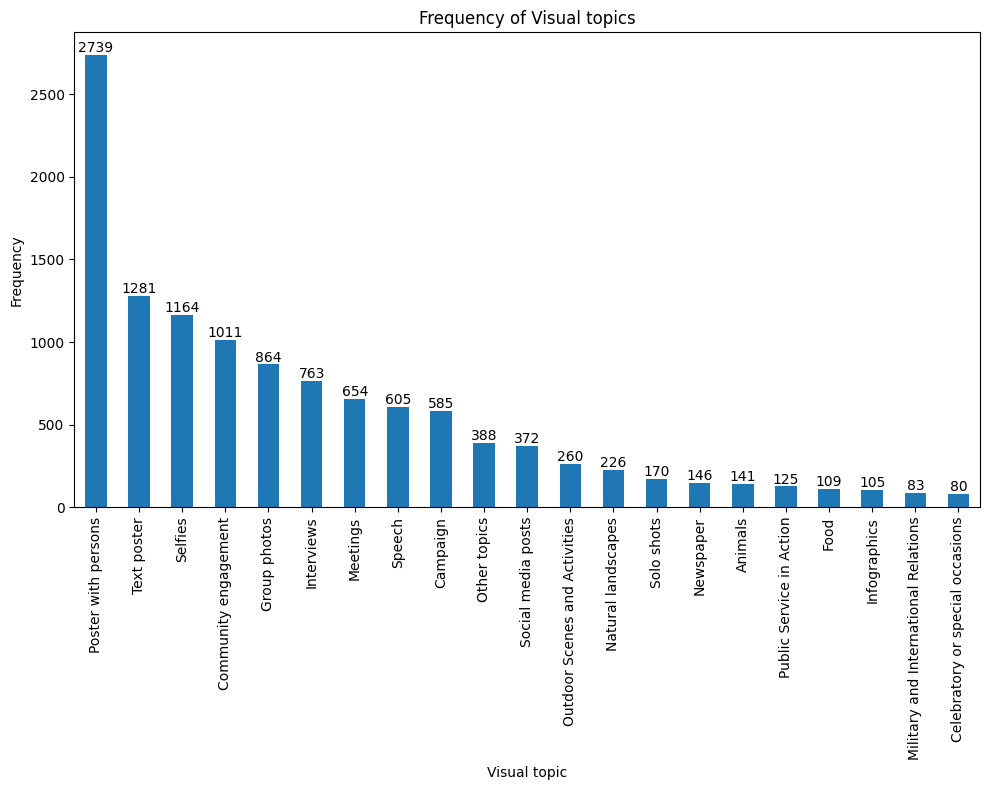

In [56]:
import matplotlib.pyplot as plt

# 统计'topic'列的频数
topic_frequency = df['topic'].value_counts()

# 绘制柱状图
plt.figure(figsize=(10, 8))
ax = topic_frequency.plot(kind='bar')

# 添加图表标题和标签
plt.title('Frequency of Visual topics')
plt.xlabel('Visual topic')
plt.ylabel('Frequency')

# 旋转x轴标签以防止重叠
plt.xticks(rotation=90)

# 在每个柱状图上方显示频数
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 保存图表为png格式
plt.tight_layout()
plt.savefig('figures/topic_frequency_chart.png')

# 展示图表
plt.show()

df = df[df['topic'] != -1]
df.shape

In [57]:
# sort by topic and probabilities
df_sorted = df.sort_values(['topic', 'probabilities'], ascending=[True, False])
df_sorted = df.sort_values(['probabilities'], ascending=[False])
# get the images names with the highest 20 probs for each topic
df_top_20 = df_sorted.groupby('topic').head(40)
df_top_20.head()

,Image,topic,probabilities
8087,ricardalong_CZwRh-XNtoH.jpg,Poster with persons,0.95
3139,joanacotar_CUP1FHYtTtW.jpg,Campaign,0.95
3118,joanacotar_CTeibjxt5RO.jpg,Selfies,0.95
6107,matthiashelferichafd_CNr2hERAxs7.jpg,Text poster,0.95
6106,matthiashelferichafd_CNPTmIXgBXs.jpg,Text poster,0.95


In [58]:
import os, sys, shutil
import numpy as np
import pandas as pd
import stat

In [59]:
base_directory = 'visual topics/'

In [60]:
def find_image_in_folder(base_dir, image_name):
    # 列出文件夹中的所有文件
    files = os.listdir(base_dir)
    
    # 检查目标文件是否在列表中
    if image_name in files:
        return os.path.join(base_dir, image_name)
    
    return None

def save_img(imges, label):
    base_dir = 'F:/phd data/post images/'  # 图片路径
    imgpath1 = find_image_in_folder(base_dir, imges)  # 递归查找图片路径
    if imgpath1:
        #imgpath2 = os.path.join('/content/drive/My Drive/Colab Notebooks/visual frames/image topic/', 'approach3', str(label), imges)  # 需要保存到的路径
        imgpath2 = os.path.join(base_directory, str(label), imges)
        os.makedirs(os.path.dirname(imgpath2), exist_ok=True)
        shutil.copy2(imgpath1, imgpath2)
        print(f"Image {imges} saved successfully.")
    else:
        print(f"Image {imges} not found in any folders.")

# 示例调用
#save_img('example_image.jpg', 'label_name')

In [61]:
df_top_20.apply(lambda row: save_img(row['Image'],row['topic']),axis=1)

Image ricardalong_CZwRh-XNtoH.jpg saved successfully.
Image joanacotar_CUP1FHYtTtW.jpg saved successfully.
Image joanacotar_CTeibjxt5RO.jpg saved successfully.
Image matthiashelferichafd_CNr2hERAxs7.jpg saved successfully.
Image matthiashelferichafd_CNPTmIXgBXs.jpg saved successfully.
Image joanacotar_CTo5kmeNrIs.jpg saved successfully.
Image joanacotar_CTOtZCpNgMV.jpg saved successfully.
Image matthiashelferichafd_CNpaaYpA_ys.jpg saved successfully.
Image jensspahn_CQ04iXqpebl.jpg saved successfully.
Image joanacotar_CTSdPMit2Fo.jpg saved successfully.
Image _svenlehmann__CUqAcKkNx3L.jpg saved successfully.
Image jensspahn_CPVaKk8o3Vh.jpg saved successfully.
Image _svenlehmann__CUUeyTGs6mC.jpg saved successfully.
Image jensspahn_CPTwTeNBLEP.jpg saved successfully.
Image joanacotar_CUaUpz9tnpv.jpg saved successfully.
Image joanacotar_CUHbeSANr8U.jpg saved successfully.
Image joanacotar_CUP1SbNtJk2.jpg saved successfully.
Image joanacotar_CYJGFOFNekt.jpg saved successfully.
Image joanac

Image maas.heiko_CWsNzSjMkgR.jpg saved successfully.
Image maas.heiko_CWU9tw-MUfr.jpg saved successfully.
Image jankorte77_CVGGuNOtAYT.jpg saved successfully.
Image jankorte77_CVIXBztt0t3.jpg saved successfully.
Image jankorte77_CVkpjewsAs0.jpg saved successfully.
Image matthiashelferichafd_CXgVtq9NE5H.jpg saved successfully.
Image jankorte77_CVNCJiEMuPg.jpg saved successfully.
Image jankorte77_CVp89iGMT6w.jpg saved successfully.
Image jankorte77_CVqQnBusrMt.jpg saved successfully.
Image _svenlehmann__CQY9OYUNpTc.jpg saved successfully.
Image matthiashelferichafd_CXeKgo5jo0p.jpg saved successfully.
Image jankorte77_CW0GG0wsk1r.jpg saved successfully.
Image jankorte77_CW5TM05jtst.jpg saved successfully.
Image jankorte77_CWf_labs7vl.jpg saved successfully.
Image matthiashelferichafd_CXbevgtNS9H.jpg saved successfully.
Image jankorte77_CWliCpAsxo_.jpg saved successfully.
Image matthiashelferichafd_CX9LdNitR8n.jpg saved successfully.
Image jankorte77_CWoN7jjse-l.jpg saved successfully.
Ima

Image hudaverdig_CVoNZhJKr-V.jpg saved successfully.
Image johannesvogel_CRyoBTbIyhv.jpg saved successfully.
Image marcobuschmann_CYKGVmXIlmG.jpg saved successfully.
Image marcobuschmann_CYgWChgI0Ij.jpg saved successfully.
Image _svenlehmann__CY59RSbN2um.jpg saved successfully.
Image marcobuschmann_CYBo6ajojeE.jpg saved successfully.
Image johannesvogel_CSG31dCoZaw.jpg saved successfully.
Image johannesvogel_CTrKwESoMbe.jpg saved successfully.
Image _svenlehmann__CZAG-vDNccN.jpg saved successfully.
Image marcobuschmann_CVfvjepDNYF.jpg saved successfully.
Image johannesvogel_CVatbNyow9Q.jpg saved successfully.
Image marcobuschmann_CV2cxzjKUWw.jpg saved successfully.
Image marcobuschmann_CUXYsWjK_GR.jpg saved successfully.
Image marcobuschmann_CUXIlIaIcKx.jpg saved successfully.
Image marcobuschmann_CUxbNJHoFOb.jpg saved successfully.
Image marcobuschmann_CUwv8ESKj38.jpg saved successfully.
Image andreas.scheuer_CQBhdcFByep.jpg saved successfully.
Image johannesvogel_CWv055UIDMM.jpg save

Image janine_wissler_CQMJA3BNvto.jpg saved successfully.
Image michellemuentefering_CU0iu_JNI7m.jpg saved successfully.
Image philipp.amthor_CT2X5mJIX70.jpg saved successfully.
Image janine_wissler_CRhmBlTMy-L.jpg saved successfully.
Image janine_wissler_CRmj5tIsdjp.jpg saved successfully.
Image _svenlehmann__CahvClfNJd3.jpg saved successfully.
Image janine_wissler_CSiAcscNuB-.jpg saved successfully.
Image philipp.amthor_CS4Px1KIDxh.jpg saved successfully.
Image michellemuentefering_CUChchgM2Vc.jpg saved successfully.
Image toni_hofreiter_CTsNXCZM5U3.jpg saved successfully.
Image toni_hofreiter_CUPiAYlMEhx.jpg saved successfully.
Image michellemuentefering_CVUQ55ENG4M.jpg saved successfully.
Image toni_hofreiter_CVsG57rs0Lx.jpg saved successfully.
Image philipp.amthor_CWjO645oTQl.jpg saved successfully.
Image janine_wissler_COVlmTlMx1h.jpg saved successfully.
Image janine_wissler_CPigAXMNNSk.jpg saved successfully.
Image michellemuentefering_CRYgw57MPHV.jpg saved successfully.
Image ph

Image marcobuschmann_CM9m-pphIv3.jpg saved successfully.
Image marcobuschmann_CPklLpqCxEL.jpg saved successfully.
Image paulziemiak_CTjoblXojCR.jpg saved successfully.
Image malte.kaufmann_CWDGL_BN5iz.jpg saved successfully.
Image marcobuschmann_CSd6i1EqcgP.jpg saved successfully.
Image marcobuschmann_CSoafhZKLOL.jpg saved successfully.
Image olafscholz_CUKt-tRMWXj.jpg saved successfully.
Image marcobuschmann_CUb_mIzqa6F.jpg saved successfully.
Image andreas.scheuer_CXG-btXoD77.jpg saved successfully.
Image matthiashelferichafd_CaX7t3IN_B5.jpg saved successfully.
Image marcobuschmann_CR4RXaqI6e2.jpg saved successfully.
Image maas.heiko_COpNLkgNQGK.jpg saved successfully.
Image adis.a93_COqMV09tOHJ.jpg saved successfully.
Image abaerbock_CUudzuTKGI8.jpg saved successfully.
Image reem.alabaliradovan_CSNQHBGKSps.jpg saved successfully.
Image maas.heiko_CRi9eGKMMj6.jpg saved successfully.
Image abaerbock_CQJcr5pqlzy.jpg saved successfully.
Image maas.heiko_CV-cMO6s1Ls.jpg saved successfull

Image abaerbock_CZ1oC5cNkIP.jpg saved successfully.
Image ricardalong_CSHHrMkMJVv.jpg saved successfully.
Image ralph_brinkhaus_CR9OUTGIGpx.jpg saved successfully.
Image ralph_brinkhaus_CRwOuWVIpnb.jpg saved successfully.
Image larsklingbeil_CXLN9FcM7jv.jpg saved successfully.
Image abaerbock_CTxhb8gMLqn.jpg saved successfully.
Image larsklingbeil_CWv_BzkoUo6.jpg saved successfully.
Image ralph_brinkhaus_CWMLEfaI3da.jpg saved successfully.
Image ralph_brinkhaus_CWLT9OFIZxu.jpg saved successfully.
Image saskiaesken_CSPZXlTMZR2.jpg saved successfully.
Image malte.kaufmann_Caed4WfNxij.jpg saved successfully.
Image malte.kaufmann_Ca90hXONGTd.jpg saved successfully.
Image ralph_brinkhaus_CTXUH0zByTo.jpg saved successfully.
Image abaerbock_CXQ0ihQtLba.jpg saved successfully.
Image saskiaesken_CSeu-SDsQFo.jpg saved successfully.
Image ralph_brinkhaus_CVf2T2IITG9.jpg saved successfully.
Image ralph_brinkhaus_CVK5NcjIZYE.jpg saved successfully.
Image abaerbock_CXToURPtWmz.jpg saved successfully

8087    None
3139    None
3118    None
6107    None
6106    None
        ... 
4088    None
4229    None
4222    None
1236    None
1903    None
Length: 840, dtype: object

In [62]:
df_top_20.shape

(840, 3)

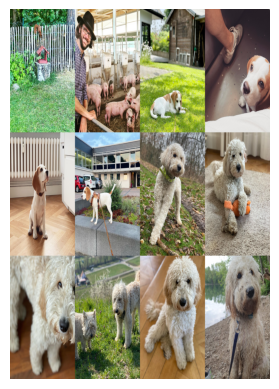

Montage saved successfully to visual topics/grid\Animals.jpg


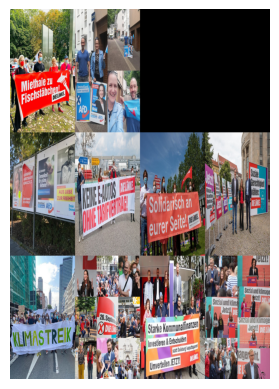

Montage saved successfully to visual topics/grid\Campaign.jpg


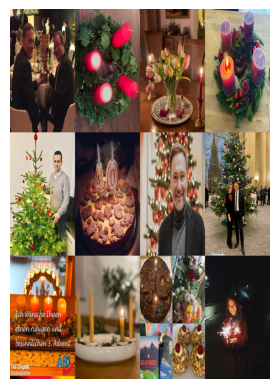

Montage saved successfully to visual topics/grid\Celebratory or special occasions.jpg


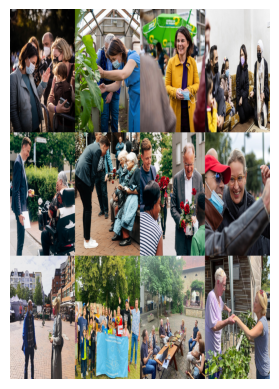

Montage saved successfully to visual topics/grid\Community engagement.jpg


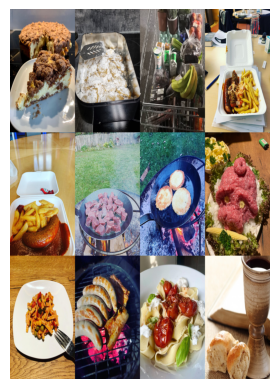

Montage saved successfully to visual topics/grid\Food.jpg


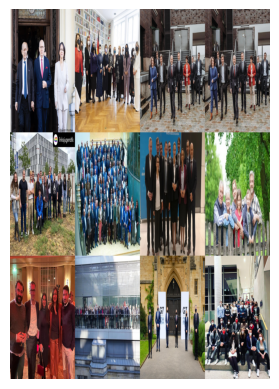

Montage saved successfully to visual topics/grid\Group photos.jpg


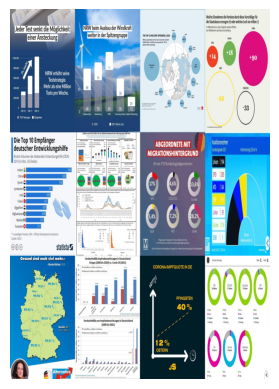

Montage saved successfully to visual topics/grid\Infographics.jpg


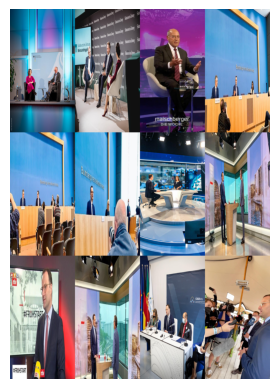

Montage saved successfully to visual topics/grid\Interviews.jpg


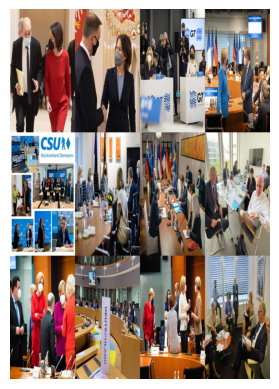

Montage saved successfully to visual topics/grid\Meetings.jpg


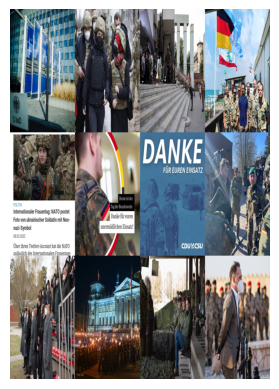

Montage saved successfully to visual topics/grid\Military and International Relations.jpg


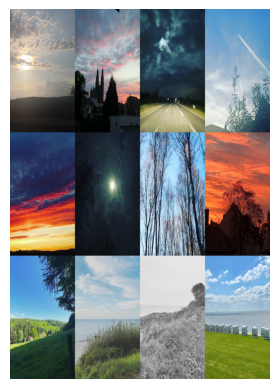

Montage saved successfully to visual topics/grid\Natural landscapes.jpg


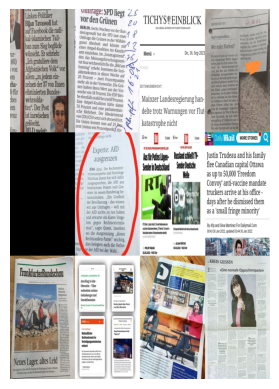

Montage saved successfully to visual topics/grid\Newspaper.jpg


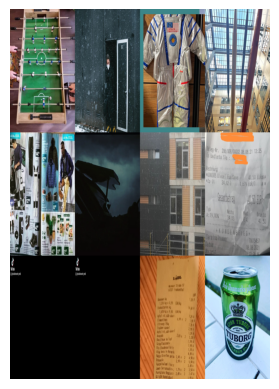

Montage saved successfully to visual topics/grid\Other topics.jpg


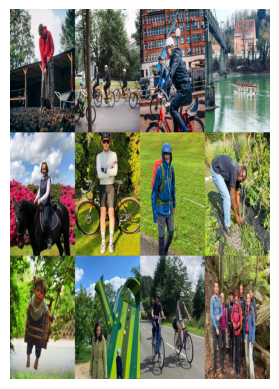

Montage saved successfully to visual topics/grid\Outdoor Scenes and Activities.jpg


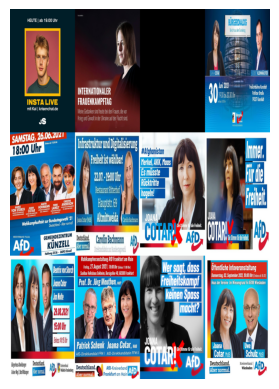

Montage saved successfully to visual topics/grid\Poster with persons.jpg


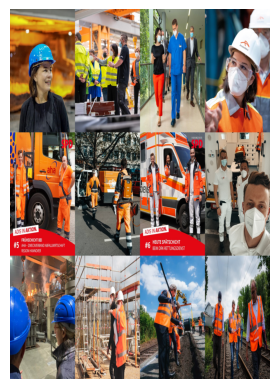

Montage saved successfully to visual topics/grid\Public Service in Action.jpg


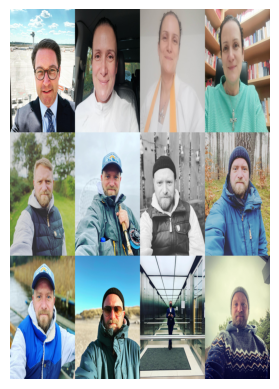

Montage saved successfully to visual topics/grid\Selfies.jpg


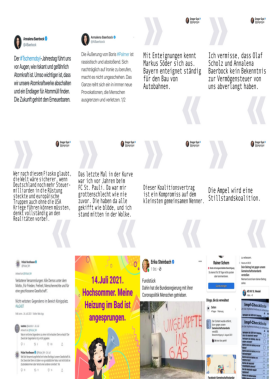

Montage saved successfully to visual topics/grid\Social media posts.jpg


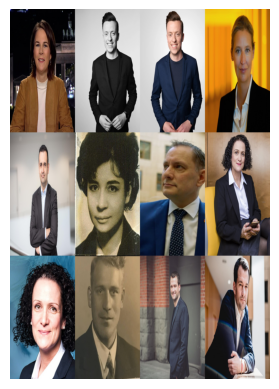

Montage saved successfully to visual topics/grid\Solo shots.jpg


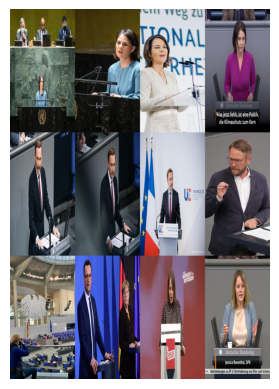

Montage saved successfully to visual topics/grid\Speech.jpg


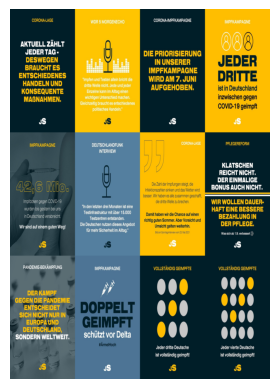

Montage saved successfully to visual topics/grid\Text poster.jpg


In [63]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

#base_directory = '/content/drive/My Drive/Colab Notebooks/visual frames/image topic 16/approach4/'
output_directory = os.path.join(base_directory, 'grid')

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Number of rows and columns in the grid, this is for 20 images.
num_rows = 3
num_cols = 4

# Image dimension to resize
target_width = 720
target_height = 1365

# Blank image to fill in the grid if there are not enough images
blank_image = np.zeros((target_height, target_width, 3), np.uint8)

# Iterate through each cored image folder
folders = [name for name in os.listdir(base_directory) if os.path.isdir(os.path.join(base_directory, name)) and name != "grid"]
for folder_index in folders:
    folder_path = os.path.join(base_directory, str(folder_index))
    image_paths = []

    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.png')):
            image_path = os.path.join(folder_path, filename)
            image_paths.append(image_path)

    # Initialize an empty list to store resized images
    resized_images = []

    # Resize images
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is not None:
            resized_image = cv2.resize(image, (target_width, target_height))
            resized_images.append(resized_image)

    # Fill in with blank images if there are not enough images
    while len(resized_images) < num_rows * num_cols:
        resized_images.append(blank_image)

    # Ensure the number of images does not exceed the grid size
    resized_images = resized_images[:num_rows * num_cols]

    # Create the montage
    montage_rows = [np.hstack(resized_images[i:i + num_cols]) for i in range(0, len(resized_images), num_cols)]
    montage = np.vstack(montage_rows)

    plt.imshow(cv2.cvtColor(montage, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Save the image (e.g., montage0, montage1, ...)
    output_filename = os.path.join(output_directory, f"{folder_index}.jpg")
    success = cv2.imwrite(output_filename, montage)

    if success:
        print(f"Montage saved successfully to {output_filename}")
    else:
        print(f"Failed to save montage to {output_filename}")

In [28]:
import os
import shutil

# 主目录，图片存储在这个路径下
base_dir = 'F:/phd data/post images/'

# 提取 'topic' 列中值为 'Other topics' 的行
other_topics_df = df[df['topic'] == 'Other topics']

# 假设图片文件名存储在 'img_name' 列中
image_names = other_topics_df['Image'].tolist()

# 目标文件夹
destination_folder = 'F:/phd data/other topic/'

# 创建目标文件夹（如果不存在）
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# 将图片复制到目标文件夹
for img_name in image_names:
    img_path = os.path.join(base_dir, img_name)  # 拼接图片完整路径
    if os.path.exists(img_path):  # 确保图片路径存在
        shutil.copy(img_path, destination_folder)
    else:
        print(f"File not found: {img_path}")

print(f"Finished copying {len(image_names)} images to {destination_folder}")

Finished copying 783 images to F:/phd data/other topic/
